# Multi-Model Ensemble — DDAMFN ×2 + ConvNeXt-V2 + Swin (RAF-DB + FER2013)

Four models trained on **RAF-DB + FER2013**, combined by **soft voting** (averaging their probabilities):

| Member | Architecture | Trained in |
|---|---|---|
| Generalist | DDAMFN (CNN + attention), fine-tuned from the RAF-DB model | `facial-emotion-multidataset` |
| DDAMFN seed 7 | same architecture, different seed + stronger augmentation | `facial-emotion-member-ddamfn` |
| ConvNeXt-V2-tiny | modern CNN, ImageNet-22k pretrained | `facial-emotion-member-convnext` |
| Swin-Tiny | vision Transformer, ImageNet-22k pretrained | `facial-emotion-member-swin` |

**Protocol.** The final ensemble is fixed in advance: an equal-weight average of the 4 members, with nothing
tuned on test data. Test sets (RAF-DB, FER2013) and the never-trained-on CK+ are each evaluated once. Other
combinations are shown only as an ablation.

## 0 · Model code (for evaluating the DDAMFN checkpoints)

In [ ]:
%%writefile MixedFeatureNet.py

from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Sequential, Module
import torch
import torch.nn as nn
class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

def l2_norm(input,axis=1):
    norm = torch.norm(input,2,axis,True)
    output = torch.div(input, norm)
    return output

class Conv_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Conv_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
        self.prelu = PReLU(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.prelu(x)
        return x

class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1):
        super(Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = Conv_block(groups, groups, groups=groups, kernel=kernel, padding=padding, stride=stride)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
  

class Swish(nn.Module):
    def __init__(self):
        super(Swish, self).__init__()

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(x)

NON_LINEARITY = {
    'ReLU': nn.ReLU(inplace=True),
    'Swish': Swish(),
}        


class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)
    
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)

        y = identity * x_w * x_h

        return y

        
class MDConv(Module):
    def __init__(self, channels, kernel_size, split_out_channels, stride):
        super(MDConv, self).__init__()
        self.num_groups = len(kernel_size)
        self.split_channels = split_out_channels
        self.mixed_depthwise_conv = nn.ModuleList()
        for i in range(self.num_groups):
            self.mixed_depthwise_conv.append(Conv2d(
                self.split_channels[i],
                self.split_channels[i],
                kernel_size[i],
                stride=stride,
                padding=kernel_size[i]//2,
                groups=self.split_channels[i],
                bias=False
            ))
        self.bn = BatchNorm2d(channels)
        self.prelu = PReLU(channels)            
       
    def forward(self, x):
        if self.num_groups == 1:
            return self.mixed_depthwise_conv[0](x)

        x_split = torch.split(x, self.split_channels, dim=1)
        x = [conv(t) for conv, t in zip(self.mixed_depthwise_conv, x_split)]
        x = torch.cat(x, dim=1)

        return x        
      
        
class Mix_Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1, kernel_size=[3,5,7], split_out_channels=[64,32,32]):
        super(Mix_Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = MDConv(channels=groups, kernel_size=kernel_size, split_out_channels=split_out_channels, stride=stride)
        self.CA = CoordAtt(groups, groups)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.CA(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output
          
class Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1)):
        super(Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        
class Mix_Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[64,64]):
        super(Mix_Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Mix_Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups, kernel_size=kernel_size, split_out_channels=split_out_channels ))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)
        

class MixedFeatureNet(Module):
    def __init__(self, embedding_size=256, out_h=7, out_w=7):
        super(MixedFeatureNet, self).__init__()
        #112x112
        self.conv1 = Conv_block(3, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1))
        #56x56
        self.conv2_dw = Conv_block(64, 64, kernel=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        self.conv_23 = Mix_Depth_Wise(64, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=128, kernel_size=[3,5,7], split_out_channels=[64,32,32] )
        
        #28x28
        self.conv_3 = Mix_Residual(64, num_block=9, groups=128, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[96,32])
        self.conv_34 = Mix_Depth_Wise(64, 128, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=256, kernel_size=[3,5,7],split_out_channels=[128,64,64] )
        
        #14x14
        self.conv_4 = Mix_Residual(128, num_block=16, groups=256, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5], split_out_channels=[192,64])
        self.conv_45 = Mix_Depth_Wise(128, 256, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=512*2, kernel_size=[3,5,7,9],split_out_channels=[128*2,128*2,128*2,128*2] )
        #7x7
        self.conv_5 = Mix_Residual(256, num_block=6, groups=512, kernel=(3, 3), stride=(1, 1), padding=(1, 1), kernel_size=[3,5,7], split_out_channels=[86*2,85*2,85*2])                
        self.conv_6_sep = Conv_block(256, 512, kernel=(1, 1), stride=(1, 1), padding=(0, 0))
        self.conv_6_dw = Linear_block(512, 512, groups=512, kernel=(out_h, out_w), stride=(1, 1), padding=(0, 0))
        self.conv_6_flatten = Flatten()
        self.linear = Linear(512, embedding_size, bias=False)
        self.bn = BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2_dw(out)
        out = self.conv_23(out)
        out = self.conv_3(out)
        out = self.conv_34(out)
        out = self.conv_4(out)
        out = self.conv_45(out)
        out = self.conv_5(out)
        out = self.conv_6_sep(out)
        out = self.conv_6_dw(out)
        out = self.conv_6_flatten(out)
        out = self.linear(out)
        out = self.bn(out)

        return l2_norm(out)

Writing MixedFeatureNet.py


In [ ]:
%%writefile DDAM.py
from torch import nn
import torch
import MixedFeatureNet
from torch.nn import Module
import os
class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = nn.Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Flatten(Module):
    def forward(self, input):
        return input.view(input.size(0), -1)
        
class DDAMNet(nn.Module):
    def __init__(self, num_class=7,num_head=2, pretrained=True):
        super(DDAMNet, self).__init__()

        net = MixedFeatureNet.MixedFeatureNet()
                
        if pretrained:
            net = torch.load(os.path.join('./pretrained/', "MFN_msceleb.pth"))       
      
        self.features = nn.Sequential(*list(net.children())[:-4])
        self.num_head = num_head
        for i in range(int(num_head)):
            setattr(self,"cat_head%d" %(i), CoordAttHead())                  
      
        self.Linear = Linear_block(512, 512, groups=512, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten()      
        self.fc = nn.Linear(512, num_class)
        self.bn = nn.BatchNorm1d(num_class)
        
    def forward(self, x):
        x = self.features(x)
        heads = []
       
        for i in range(self.num_head):
            heads.append(getattr(self,"cat_head%d" %i)(x))
        head_out =heads
        
        y = heads[0]
        
        for i in range(1,self.num_head):
            y = torch.max(y,heads[i])                     
        
        y = x*y
        y = self.Linear(y)
        y = self.flatten(y) 
        out = self.fc(y)        
        return out, x, head_out
        
class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6(inplace=inplace)
    def forward(self, x):
        return self.relu(x + 3) / 6
                      
class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super(h_swish, self).__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)
    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAttHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.CoordAtt = CoordAtt(512,512)
    def forward(self, x):
        ca = self.CoordAtt(x)
        return ca  
        
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
      
        self.Linear_h = Linear_block(inp, inp, groups=inp, kernel=(1, 7), stride=(1, 1), padding=(0, 0))        
        self.Linear_w = Linear_block(inp, inp, groups=inp, kernel=(7, 1), stride=(1, 1), padding=(0, 0))
        
        mip = max(8, inp // groups)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.conv2 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv3 = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.relu = h_swish()
        self.Linear = Linear_block(oup, oup, groups=oup, kernel=(7, 7), stride=(1, 1), padding=(0, 0))
        self.flatten = Flatten() 

    def forward(self, x):
        identity = x
        n,c,h,w = x.size()
        x_h = self.Linear_h(x)
        x_w = self.Linear_w(x)
        x_w = x_w.permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.relu(y) 
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        x_h = self.conv2(x_h).sigmoid()
        x_w = self.conv3(x_w).sigmoid()
        x_h = x_h.expand(-1, -1, h, w)
        x_w = x_w.expand(-1, -1, h, w)
        
        y = x_w * x_h
 
        return y

Writing DDAM.py


## 1 · Data, checkpoints and member logits

In [ ]:
import os, sys, json, glob, numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
sys.path.insert(0, os.getcwd())
from DDAM import DDAMNet

DATA = os.environ.get('DATA_ROOT', '/kaggle/input'); OUT = os.environ.get('OUT_ROOT', '/kaggle/working')
os.makedirs(OUT, exist_ok=True); DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
FOLDER2EMO = {'angry': 'Anger', 'anger': 'Anger', 'disgust': 'Disgust', 'fear': 'Fear', 'happy': 'Happiness',
              'happiness': 'Happiness', 'neutral': 'Neutral', 'sad': 'Sadness', 'sadness': 'Sadness', 'surprise': 'Surprise'}
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

train_csv = test_csv = None; CKPTS = {}; NPZ = []; IMG = {}; FER_TE, CK = [], []
for root, _, files in os.walk(DATA):
    low = root.lower().replace('\\', '/'); parent = os.path.basename(root).lower()
    for f in files:
        p = os.path.join(root, f)
        if   f == 'train_labels.csv': train_csv = p
        elif f == 'test_labels.csv':  test_csv = p
        elif f == 'ddamfn_raf_fer_generalist.pth': CKPTS['Generalist (DDAMFN)'] = p
        elif f == 'ddamfn_rafdb_final.pth':        CKPTS['Specialist (RAF-DB only)'] = p
        elif f.startswith('logits_') and f.endswith('.npz'): NPZ.append(p)
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')):
            emo = FOLDER2EMO.get(parent)
            if emo and 'fer' in low and '/test' in low: FER_TE.append((p, CLASS_NAMES.index(emo)))
            elif emo and 'fer' in low and '/train' in low: pass
            elif emo and 'ck' in low: CK.append((p, CLASS_NAMES.index(emo)))
            else: IMG[f] = p
def dedup(items):
    seen, out = set(), []
    for p, y in items:
        k = (y, os.path.basename(p))
        if k not in seen: seen.add(k); out.append((p, y))
    return out
FER_TE, CK = dedup(FER_TE), dedup(CK)
raf_test_df = pd.read_csv(test_csv)
RAF_TE = [(IMG[n], int(l) - 1) for n, l in zip(raf_test_df['image'], raf_test_df['label'])]
EVALS = {'raf_test': RAF_TE, 'fer_test': FER_TE, 'ck': CK}
key = lambda p, y: f'{y}/{os.path.basename(p)}'
KEYS = {k: [key(p, y) for p, y in v] for k, v in EVALS.items()}
Y = {k: np.array([y for _, y in v]) for k, v in EVALS.items()}
print('test sets:', {k: len(v) for k, v in EVALS.items()}, '| checkpoints:', list(CKPTS), '| member files:', [os.path.basename(p) for p in NPZ])

test sets: {'raf_test': 3068, 'fer_test': 7178, 'ck': 927} | checkpoints: ['Generalist (DDAMFN)', 'Specialist (RAF-DB only)'] | member files: ['logits_ddamfn_s7.npz', 'logits_convnext_s11.npz', 'logits_swin_s23.npz']


In [ ]:
softmax = lambda z: np.exp(z - z.max(1, keepdims=True)) / np.exp(z - z.max(1, keepdims=True)).sum(1, keepdims=True)
PROBS = {}   # model name -> {eval set -> probabilities aligned to KEYS}

# members: align saved logits to our item order by image key
NICE = {'ddamfn': 'DDAMFN seed 7', 'convnext': 'ConvNeXt-V2-tiny', 'swin': 'Swin-Tiny'}
for p in sorted(NPZ):
    d = np.load(p, allow_pickle=False); arch = os.path.basename(p).split('_')[1]; name = NICE.get(arch, arch)
    PROBS[name] = {}
    for k in EVALS:
        idx = {kk: i for i, kk in enumerate(d[f'{k}_keys'])}
        missing = [kk for kk in KEYS[k] if kk not in idx]
        assert not missing, f'{name}/{k}: {len(missing)} images missing from member logits'
        PROBS[name][k] = softmax(d[f'{k}_logits'][[idx[kk] for kk in KEYS[k]]])

# DDAMFN checkpoints evaluated here
tf = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor(),
                         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
class Faces(Dataset):
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i): p, y = self.items[i]; return tf(Image.open(p).convert('RGB')), y
for name, path in CKPTS.items():
    m = DDAMNet(num_class=7, num_head=2, pretrained=False).to(DEVICE)
    ck = torch.load(path, map_location=DEVICE, weights_only=False); m.load_state_dict(ck.get('model_state_dict', ck)); m.eval()
    PROBS[name] = {}
    for k, items in EVALS.items():
        out = []
        with torch.no_grad():
            for x, _ in DataLoader(Faces(items), batch_size=256, num_workers=int(os.environ.get('WORKERS', 4))):
                out.append(m(x.to(DEVICE))[0].float().cpu())
        PROBS[name][k] = softmax(torch.cat(out).numpy())
print('models:', list(PROBS))

models: ['Swin-Tiny', 'ConvNeXt-V2-tiny', 'DDAMFN seed 7', 'Generalist (DDAMFN)', 'Specialist (RAF-DB only)']


## 2 · Single models vs ensembles

In [ ]:
def score(P, k):
    p = P.argmax(1); return 100 * (p == Y[k]).mean(), 100 * balanced_accuracy_score(Y[k], p)
MAIN = [n for n in ['Generalist (DDAMFN)', 'DDAMFN seed 7', 'ConvNeXt-V2-tiny', 'Swin-Tiny'] if n in PROBS]
COMBOS = {
    f'★ Ensemble: {len(MAIN)} multi-dataset models (final)': MAIN,
    'Ensemble: CNN + Transformer (ConvNeXt + Swin)': [n for n in ['ConvNeXt-V2-tiny', 'Swin-Tiny'] if n in PROBS],
    'Ensemble: two DDAMFNs': [n for n in ['Generalist (DDAMFN)', 'DDAMFN seed 7'] if n in PROBS],
    'Ensemble: final + RAF-DB specialist': MAIN + (['Specialist (RAF-DB only)'] if 'Specialist (RAF-DB only)' in PROBS else []),
}
rows = []
for name in PROBS:
    rows.append((name, *[v for k in EVALS for v in score(PROBS[name][k], k)]))
for cname, members in COMBOS.items():
    if len(members) < 2: continue
    rows.append((cname, *[v for k in EVALS for v in score(np.mean([PROBS[n][k] for n in members], 0), k)]))
df = pd.DataFrame(rows, columns=['model', 'RAF-DB', 'RAF-DB mc', 'FER2013', 'FER2013 mc', 'CK+ (unseen)', 'CK+ mc']).round(2)
pd.set_option('display.width', 200); print(df.to_string(index=False))
df.to_csv(os.path.join(OUT, 'ensemble_results.csv'), index=False)

                                        model  RAF-DB  RAF-DB mc  FER2013  FER2013 mc  CK+ (unseen)  CK+ mc
                                    Swin-Tiny   88.10      80.26    69.00       65.47         69.90   64.77
                             ConvNeXt-V2-tiny   88.49      79.51    70.45       68.02         75.51   70.56
                                DDAMFN seed 7   91.40      85.39    68.32       63.75         81.88   76.13
                          Generalist (DDAMFN)   90.81      84.45    69.00       64.77         78.96   73.40
                     Specialist (RAF-DB only)   91.07      84.64    55.29       50.89         77.02   69.16
   ★ Ensemble: 4 multi-dataset models (final)   91.98      84.99    71.72       68.32         77.56   72.76
Ensemble: CNN + Transformer (ConvNeXt + Swin)   89.57      81.74    70.79       68.29         74.00   68.92
                        Ensemble: two DDAMFNs   91.30      84.83    69.18       64.63         80.80   75.60
          Ensemble: final + 

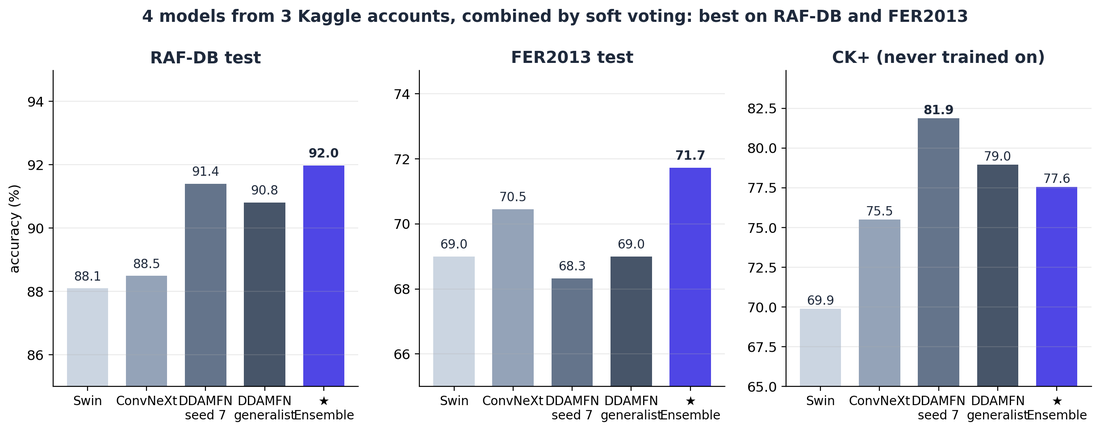

In [ ]:
final = [r for r in rows if r[0].startswith('★')][0]
singles = [r for r in rows if not r[0].startswith(('★', 'Ensemble'))]
labels = [r[0] for r in singles] + ['★ Ensemble']; data = singles + [final]
cols = ['#cbd5e1', '#94a3b8', '#64748b', '#475569', '#334155', '#4f46e5'][-len(data):]
fig, axs = plt.subplots(1, 3, figsize=(15, 4.6), sharey=False)
for a, (title, ci) in zip(axs, [('RAF-DB test', 1), ('FER2013 test', 3), ('CK+ (never trained on)', 5)]):
    v = [r[ci] for r in data]; bars = a.bar(range(len(v)), v, color=cols[:len(v)] if len(v) <= len(cols) else None)
    bars[-1].set_color('#4f46e5')
    for b, val in zip(bars, v): a.text(b.get_x() + b.get_width() / 2, val + .3, f'{val:.1f}', ha='center', fontsize=9)
    a.set_title(title, fontweight='bold'); a.set_xticks(range(len(v))); a.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    a.set_ylim(min(v) - 6, max(v) + 3)
axs[0].set_ylabel('accuracy (%)')
fig.suptitle('Soft-voting ensemble vs. individual models', fontweight='bold', y=1.02)
fig.savefig(os.path.join(OUT, 'ensemble_vs_singles.png'), bbox_inches='tight', facecolor='white'); plt.show()
json.dump({'rows': [list(map(lambda x: x if isinstance(x, str) else round(float(x), 2), r)) for r in rows],
           'columns': list(df.columns), 'final_members': MAIN}, open(os.path.join(OUT, 'ensemble_results.json'), 'w'), indent=2)